# **Idemia Datachallenge (IADATA704): Face Occlusion Prediction**

**Group Name:** Team GPU  
**Group Number:** 21  
**Team Members:** Oscar DE LA CRUZ, Rémi HAMON  

**Project repository:** [https://github.com/odelacruz-fierro/data-challenge-idemia.git](https://github.com/odelacruz-fierro/data-challenge-idemia.git)

---

In [96]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


from src import config


# Check files existence
files = [config.DF_TRAIN,
         config.DF_TEST,
         config.IMAGE_TEST]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/train.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/test_students.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/crops/Crop_224_5fp_100K/database1/img00000048.webp


## **Dataset overview**

In [34]:
df_train = pd.read_csv(config.DF_TRAIN, delimiter=',')
df_train = df_train.dropna()

df_test = pd.read_csv(config.DF_TEST, delimiter=',')
df_test = df_test.dropna()

In [18]:
df_train.info()
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   filename       100000 non-null  str    
 1   FaceOcclusion  100000 non-null  float64
 2   gender         100000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 2.3 MB


,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [52]:
df_test.info()
df_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 29980 entries, 0 to 29979
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  29980 non-null  str  
dtypes: str(1)
memory usage: 234.3 KB


,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


## **Occlusion distribution**

Stats
min_val =	0.00
max_val =	1.00
mean_val =	0.08
median_val =	0.05



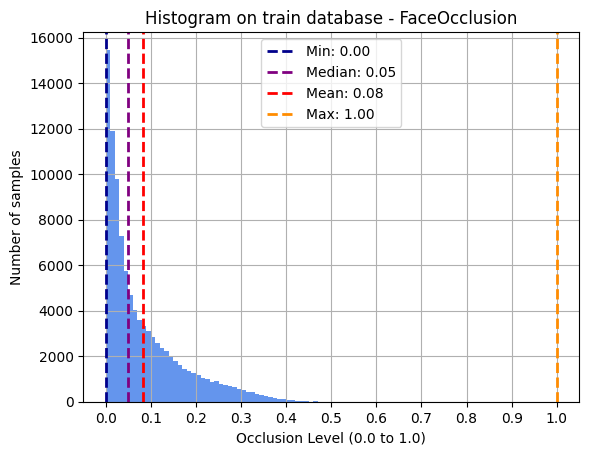

In [94]:
min_val = df_train['FaceOcclusion'].min()
max_val = df_train['FaceOcclusion'].max()
mean_val = df_train['FaceOcclusion'].mean()
median_val = df_train['FaceOcclusion'].median()

print("=================================")
print("Stats")
print("=================================")
print(f"min_val =\t{min_val:.2f}")
print(f"max_val =\t{max_val:.2f}")
print(f"mean_val =\t{mean_val:.2f}")
print(f"median_val =\t{median_val:.2f}")
print()


hist_occlusion = df_train.hist(column = ['FaceOcclusion'], bins = 100, color='cornflowerblue')

ax = hist_occlusion[0,0]
ax.set_title(f"Histogram on train database - FaceOcclusion")

# Add vertical lines
ax.axvline(min_val, color='#00008B', linestyle='dashed', linewidth=2, label=f'Min: {min_val:.2f}')
ax.axvline(median_val, color= '#800080', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')
ax.axvline(mean_val, color='#FF0000', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
ax.axvline(max_val, color='#FF8C00', linestyle='dashed', linewidth=2, label=f'Max: {max_val:.2f}')

# Set horizontal axis units
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_ylabel("Number of samples")
ax.set_xlabel("Occlusion Level (0.0 to 1.0)")
ax.legend()


plt.savefig('report/figures/occlusion_distribution.pdf', bbox_inches='tight')
plt.show()

## **Gender distribution**

67.60 % are Men 
32.40 % are Women


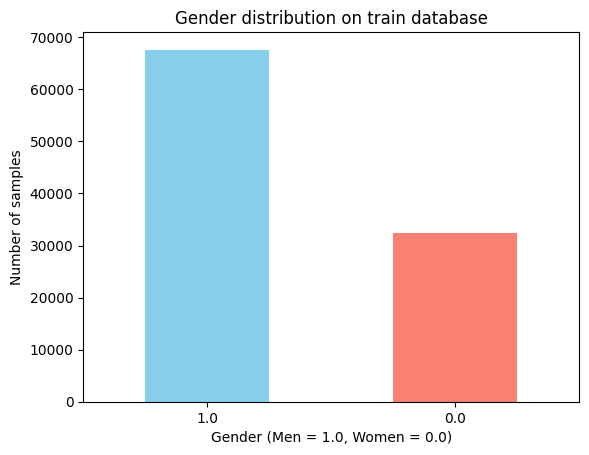

In [95]:
gender_counts = df_train['gender'].value_counts()

#print(gender_counts)
total = gender_counts.sum()
print(f"{(gender_counts[1]/total)*100:.2f} % are Men ")
print(f"{(gender_counts[0]/total)*100:.2f} % are Women")

gender_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Gender distribution on train database")
plt.xlabel("Gender (Men = 1.0, Women = 0.0)")
plt.ylabel("Number of samples")
plt.xticks(rotation=0) # Pour garder les labels horizontaux
plt.savefig('report/figures/gender_distribution.pdf', bbox_inches='tight')
plt.show()

## **Images display**

Here we aim to display random images on three occlusion invertals:

- Bottom interval $[0.0, 0.3]$
- Medium interval $[0.31, 0.6]$
- Top interval $[0.6, 1.0]$

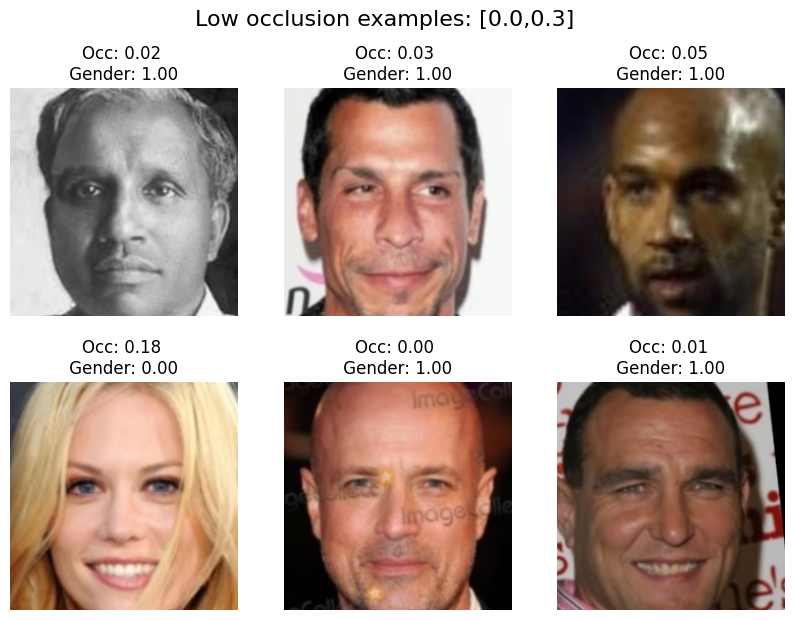

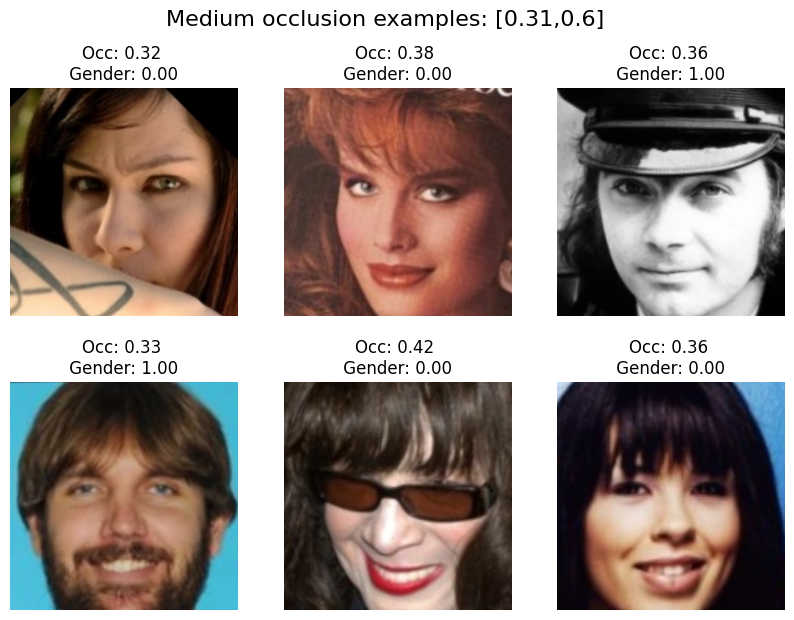

In [ ]:
def display_mosaic(df, interval, title):
    
    # Apply interval
    df_subset = df[(df['FaceOcclusion'] >= interval[0]) & (df['FaceOcclusion'] <= interval[1])]
    samples = df_subset.sample(n=min(6, len(df_subset)), random_state = 42)

    fig, axes = plt.subplots(2,3, figsize = (10,7))
    axes = axes.flatten()
    fig.suptitle(f"{title} examples: [{interval[0]},{interval[1]}]", fontsize=16)

    files = []
    for i, (idx, row) in enumerate(samples.iterrows()):

        filename = row['filename']
        occlusion = row['FaceOcclusion']
        gender = row['gender']
        
        # Load image
        FILE_DIR = f"/{config.IMAGE_DIR}/{filename}"
        files.append(FILE_DIR)
        img2display = Image.open(FILE_DIR)
        
        axes[i].imshow(img2display)
        axes[i].set_title(f"Occ: {occlusion:.2f} \n Gender: {gender:.2f} ")
        
        axes[i].axis('off') # Hide axes for cleaner look

        ax.imshow(img2display)

    return files

def display_mosaic_3x3(df, files_low, files_med, files_high):
    
    # Create a 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(7, 9))
    fig.suptitle("Occlusion level samples", fontsize=16, y=0.95)
    
    # Organize lists into a structure for easier looping
    rows_data = [files_low, files_med, files_high]
    row_labels = ["Low", "Medium", "High"]
    
    for row_idx, file_list in enumerate(rows_data):

        for col_idx in range(3):
            # Access specific axes (3 rows, 3 columns)
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(file_list):
                
                file_path = file_list[col_idx]
                
                # Recover row from DF
                row = df[df['filename'].apply(lambda x: x in file_path)].iloc[0]
                
                # Load and display
                img = Image.open(file_path)
                ax.imshow(img)
                ax.set_title(f"{row_labels[row_idx]}: {row['FaceOcclusion']:.2f}")
                ax.axis('off')
            else:
                ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('report/figures/occlusion_mosaic.pdf', bbox_inches='tight')
    plt.show()


files_low = display_mosaic(df_train, [0.0,0.3], "Low occlusion")
files_medium = display_mosaic(df_train, [0.31,0.6], "Medium occlusion")
files_high = display_mosaic(df_train, [0.61,1.0], "High occlusion")

display_mosaic_3x3(df_train, files_low, files_medium, files_high)